# Text Embeddings using Universal Sentence Encoder

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow.keras as keras

In [ ]:
from dotenv import load_env

In [ ]:
model_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model = hub.load(model_url)

In [ ]:
def embed(input_text, embed_model=model):
    return embed_model(input_text)

In [ ]:
embeddings = embed(['This is a sentence'])

In [ ]:
embeddings

<tf.Tensor: shape=(1, 512), dtype=float32, numpy=
array([[ 0.02881767, -0.02020015,  0.01069628,  0.0385053 , -0.09253702,
         0.01752774, -0.04711751,  0.0478521 ,  0.01430713,  0.02635952,
         0.02157276, -0.04987606,  0.03023818,  0.11923701,  0.04333102,
        -0.11343763, -0.02569381,  0.00875983, -0.03205026, -0.03528893,
         0.065098  ,  0.07168703,  0.00487422, -0.00622953, -0.05483385,
         0.06636366,  0.02197697, -0.08987362,  0.03663914, -0.04186109,
         0.03020706, -0.02176558,  0.00683554, -0.04167067, -0.09498136,
        -0.03249762,  0.06278758,  0.04457697,  0.00825471, -0.02461435,
        -0.00744968,  0.00276056,  0.04595318,  0.0438056 , -0.06370507,
        -0.01170835, -0.05826195, -0.02410091, -0.035766  , -0.03617879,
        -0.01113707, -0.0866305 , -0.08743551,  0.00281444, -0.01570992,
        -0.04420159,  0.0287745 ,  0.03433856, -0.0100031 , -0.04693236,
         0.00529842, -0.05397878,  0.01005255, -0.01533142, -0.05143673,
 

## Semenatic Similarity Scoring

In [ ]:
from numpy.linalg import norm

In [ ]:
def cos_sim(A, B):
    return np.inner(A,B)/(norm(A)*norm(B))

def euclidean(A,B):
    return norm(A-B)

In [ ]:
def is_it_sim(textA, textB, thresh=.25, sim_func=cos_sim):
    embeddingsA = embed([textA])
    embeddingsB = embed([textB])
    sim_score = sim_func(embeddingsA, embeddingsB)
    if sim_score > thresh:
        print("They are SIMILAR!")
    else:
        print("Not at all...")
    return sim_score, sim_score>thresh

In [ ]:
QuestionA = 'This is a technology that builds computers'

AnswerA = ' I had a delicious fruit called an apple'
AnswerB = 'I am writing a program on my Apple laptop'

is_it_sim(QuestionA, AnswerA)

Not at all...


(array([[0.07709729]], dtype=float32), array([[False]]))

In [ ]:
is_it_sim(QuestionA, AnswerB)

They are SIMILAR!


(array([[0.26977792]], dtype=float32), array([[ True]]))

# Text Classification using Embeddings and GUSE

In [ ]:
!pip install tf_keras
!pip install tensorflow_datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow.keras as keras
import tf_keras

import tensorflow_datasets as tfds

In [ ]:
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews",
    split=('train[:60%]','train[60%:]','test'),
    as_supervised =True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.FP8JAM_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.FP8JAM_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.FP8JAM_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [ ]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(10)))

## Load Hub Layer and Create a Hub Layer

In [ ]:
embedding_model_url = 'https://tfhub.dev/google/universal-sentence-encoder/4'

In [ ]:
hub_layer = hub.KerasLayer(embedding_model_url, input_shape=[], dtype=tf.string, trainable=False)

## Build a Neural Net Text Classifier

In [ ]:
nlp_model = tf_keras.Sequential()

In [ ]:
nlp_model.add(hub_layer)
nlp_model.add(tf_keras.layers.Dense(256, activation='relu'))
nlp_model.add(tf_keras.layers.Dropout(.1))
nlp_model.add(tf_keras.layers.Dense(128, activation='relu'))
nlp_model.add(tf_keras.layers.Dropout(.1))
nlp_model.add(tf_keras.layers.Dense(64, activation='relu'))
nlp_model.add(tf_keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
nlp_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 512)               256797824 
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 1)                 6

## Compile and Train NLP Model

In [ ]:
nlp_model.compile(optimizer='Adam', loss=tf_keras.losses.BinaryCrossentropy(from_logits=False), metrics=['binary_accuracy'])

In [ ]:
train_data.batch(512)

<_BatchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
history = nlp_model.fit(train_data.batch(512), epochs=20, validation_data=validation_data.batch(512), verbose=2)

Epoch 1/20
30/30 - 41s - loss: 0.2529 - binary_accuracy: 0.8991 - val_loss: 0.3326 - val_binary_accuracy: 0.8634 - 41s/epoch - 1s/step
Epoch 2/20
30/30 - 28s - loss: 0.2282 - binary_accuracy: 0.9132 - val_loss: 0.3451 - val_binary_accuracy: 0.8586 - 28s/epoch - 930ms/step
Epoch 3/20
30/30 - 27s - loss: 0.2070 - binary_accuracy: 0.9202 - val_loss: 0.3525 - val_binary_accuracy: 0.8582 - 27s/epoch - 900ms/step
Epoch 4/20
30/30 - 27s - loss: 0.1863 - binary_accuracy: 0.9299 - val_loss: 0.3795 - val_binary_accuracy: 0.8515 - 27s/epoch - 902ms/step
Epoch 5/20
30/30 - 28s - loss: 0.1702 - binary_accuracy: 0.9376 - val_loss: 0.3734 - val_binary_accuracy: 0.8602 - 28s/epoch - 918ms/step
Epoch 6/20


KeyboardInterrupt: 

## Model Evaluation

In [ ]:
results = nlp_model.evaluate(test_data.batch(512), verbose=2)

49/49 - 27s - loss: 0.4321 - binary_accuracy: 0.8356 - 27s/epoch - 560ms/step


## Model Save

In [ ]:
import os
if not os.path.exists('/content/TFModels/'):
  os.mkdir('/content/TFModels/')

In [ ]:
nlp_model.save('/content/TFModels')

## Inference Function

In [ ]:
def get_sentiment(text, model=nlp_model, thresh=0.5):
  p_hat =model.predict([text])[0][0]
  out = (p_hat>thresh).astype('int32')

  print("Viewer Comment:\n"+text+"\n\n The Review was:")
  if out: print(" It was Good!")
  else: print("Bad Movie!")
  return p_hat


In [ ]:
get_sentiment('It was Dynamite! Will see again, and again, if I wanted to barf a lot!')

1/1 [==============================] - 0s 36ms/step
Viewer Comment:
It was Dynamite! Will see again, and again, if I wanted to barf a lot!

 The Review was:
Bad Movie!


np.float32(0.0078052534)

In [ ]:
get_sentiment("Few times in my life a movie makes me think about the truth and beauty in the world")

1/1 [==============================] - 0s 72ms/step
Viewer Comment:
Few times in my life a movie makes me think about the truth and beauty in the world

 The Review was:
 It was Good!


np.float32(0.9924534)

# K Means Clustering


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
N = 1001
D =2
X=[]
means=[]
k = 5

for i in range(k):
  X.append(np.random.randn(N,D)+np.random.randn(1,D)*5)
  means.append(np.mean(X[-1], axis=0))

X=np.vstack(X)
means =np.vstack(means)

In [57]:
means_np = np.array(means)
means_np.shape

(5, 2)

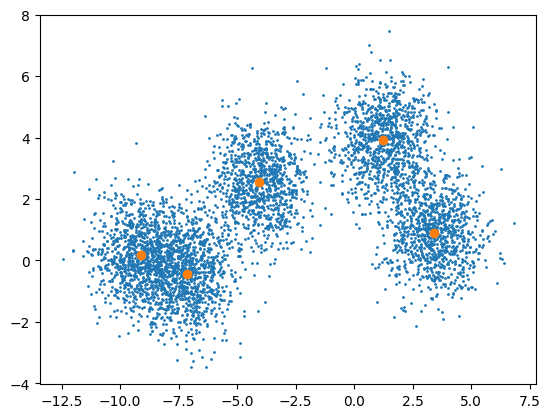

In [58]:
plt.figure()
plt.scatter(X[:,0], X[:,1], s=1)
plt.scatter(means_np[:,0], means_np[:,1])
plt.show()

In [59]:
def Distance(X, means,*args,**kwargs):
  diff=[]
  dists=[]
  for mean in means:
    diff=X-mean
    dist=np.sqrt(np.sum(diff**2,axis=1, keepdims=True))
    dists.append(dist)
  return np.hstack(dists)

In [60]:
class K_Means:
  def __init__(self, k=3, distance_func=Distance, beta=None):
    self.k=k
    self.distance_func=distance_func
    self.beta=beta

  def fit(self, X, iterations = 5):
    indices =np.arange(X.shape[0])
    sample_indices = np.random.choice(indices, size=self.k, replace=False)
    self.means =X[sample_indices]

    for i in range(iterations):
      plt.subplot(iterations//4 + 1, 4, i+1)
      y_hat = self.predict(X)
      self.means=[]
      for j in range(self.k):
        mean =np.mean(X[y_hat==j], axis=0)
        self.means.append(mean)
      self.means =np.vstack(self.means)

      # plt.figure()
      plt.scatter(X[:,0],X[:,1], s=1, c=y_hat)
      plt.scatter(self.means[:,0],self.means[:,1], c='k', s=9)
    plt.show()

    y_hat = self.predict(X)
    plt.figure()
    plt.scatter(X[:,0],X[:,1], s=1, c=y_hat)
    plt.scatter(self.means[:,0],self.means[:,1], c='k', s=9)
    plt.show()
    return y_hat

  def predict(self, X):
    dist = self.distance_func(X, self.means, self.beta)
    y_hat = np.argmin(dist, axis=1)
    return y_hat



In [61]:
kmeans_dist = K_Means(k=5)

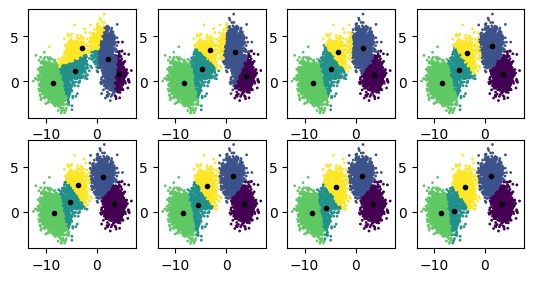

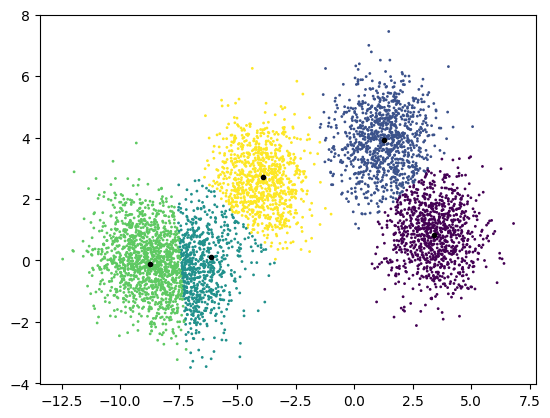

In [62]:
y_hat = kmeans_dist.fit(X, iterations=8)

# Unsupervised NLP Topic Modeling using Embeddings

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpy.linalg as lg
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras

In [64]:
embedding_model_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model_guse = hub.load(embedding_model_url)

In [65]:
def text_embed_guse_512(input_text):
  sentence_in = [input_text]
  return model_guse(sentence_in)

## Load Data to be Clustered


In [66]:
file_path = '/content/data_elonmusk2.csv'

In [67]:
pd.read_csv(file_path, encoding='iso-8859-1').tail()

,row ID,Tweet,Time,Retweet from,User
3213,Row3213,"@YOUSRC Amos's article was fair, but his edito...",11/20/2012 8:52,NaN,elonmusk
3214,Row3214,These articles in Space News describe why Aria...,11/20/2012 8:38,NaN,elonmusk
3215,Row3215,Was misquoted by BBC as saying Europe's rocket...,11/20/2012 8:30,NaN,elonmusk
3216,Row3216,Just returned from a trip to London and Oxford...,11/19/2012 8:59,NaN,elonmusk
3217,Row3217,RT @Jon_Favreau: My Model S just arrived and I...,11/16/2012 17:59,Jon_Favreau,elonmusk


In [68]:
def data_load(file_path):
  data = pd.read_csv(file_path, encoding='iso-8859-1')
  X = data.Tweet
  return X

In [69]:
def generate_ids(number, size):
  import string, random
  ids=[]
  for i in range(number):
    res = ''.join(random.choices(string.ascii_letters, k=size))
    ids.append(res)
    if len(set(ids)) != i+1:
      i-=1
      ids.pop(-1)

  return ids


In [73]:
def populate_Index(X, embed_func=text_embed_guse_512):
  dict_of_sentences = {}
  N = len(X)
  ids = generate_ids(N, 7)
  for i in range(N):
    # print(X[i])
    dict_of_sentences[i] = {"unique_id":ids[i], "Vector":embed_func(X[i]).numpy(), "Metadata":{"text":X[i]}}
  return dict_of_sentences

In [74]:
X = data_load(file_path)

In [75]:
tweet_index = populate_Index(X)

In [76]:
tweet_index[23]

{'unique_id': 'MqBCUzU',
 'Vector': array([[-5.41965291e-02, -6.40161037e-02,  4.56826948e-03,
         -2.43067406e-02,  2.43720040e-02, -5.60916327e-02,
         -2.53111105e-02, -1.68745890e-02, -8.01746920e-02,
         -9.05051157e-02, -3.25682499e-02,  1.32230558e-02,
          3.19364853e-02, -8.95939767e-02,  1.97230317e-02,
          1.06919827e-02,  1.16682397e-02, -8.03494651e-04,
          5.62556088e-02, -6.62942454e-02, -1.06742065e-02,
         -3.28763276e-02,  2.81777121e-02,  7.62109309e-02,
         -5.93735185e-03, -3.76911759e-02, -5.65260276e-02,
          2.74753422e-02, -5.13492636e-02,  2.59850174e-02,
          2.14633700e-02, -2.44961656e-03,  6.90590544e-03,
         -6.77865045e-03, -5.02794273e-02, -3.85192744e-02,
         -1.68059710e-02,  7.32877031e-02,  1.75549127e-02,
         -4.46230434e-02,  4.22467440e-02, -1.22216148e-02,
         -4.09687683e-02,  6.12836443e-02,  1.91107243e-02,
          1.29112359e-02,  2.37234328e-02,  4.72378805e-02,
     

## Clustering using K Means on Embeddings

In [77]:
def Train_data_from_Index(my_index_dict):
  return np.vstack([my_index_dict[i]['Vector'] for i in range(len(my_index_dict))])

In [78]:
X_tweets = Train_data_from_Index(tweet_index)

In [79]:
X_tweets.shape

(3218, 512)

In [80]:
def Distance(X, means,*args,**kwargs):
  diff=[]
  dists=[]
  for mean in means:
    diff=X-mean
    dist=np.sqrt(np.sum(diff**2,axis=1, keepdims=True))
    dists.append(dist)
  return np.hstack(dists)

In [85]:
def Responsibility(X,means,beta=1e-3,*args,**kwargs):
  diff=[]
  responsibilities=[]

  for mean in means:
    diff =X -mean
    dist =(np.sum(diff ** 2,axis=1,keepdims=True))

    numerator= np.exp(-(beta*dist))
    denominator=np.sum(numerator)
    responsibility=-numerator/denominator

    responsibilities.append(responsibility)
  return np.hstack(responsibilities)

In [81]:
def cluster_embeddings(X, distance_func=Distance, k=6, beta=0, iterations=20):
  kmeans =K_Means(k=k, distance_func=distance_func, beta=beta)
  y_hat=kmeans.fit(X, iterations=20)
  centroid_tweet_indices=[]
  print(y_hat)
  for cluster in range(k):
    centroid=kmeans.means[cluster]
    dists=np.sqrt(np.sum((centroid-X)**2,axis=1, keepdims=True))
    closest_index=np.argmin(dists)
    centroid_tweet_indices.append(closest_index)
  return centroid_tweet_indices,y_hat

In [82]:
def display_tweet_clusters(index_dict,name_index, obs_per_cluster,y_hat):
  k = len(set(y_hat))
  for j in range(k):
    count=0
    print("Representative Obs:"+index_dict[name_index[j]]["Metadata"]['text']+"\n")
    for i in range(len(index_dict)):
      if y_hat[i]==j:
        count+=1

        print("Cluster: "+str(y_hat[i])+" Tweet: "+index_dict[i]["Metadata"]['text'])
      if count>obs_per_cluster:break
    print('\n')


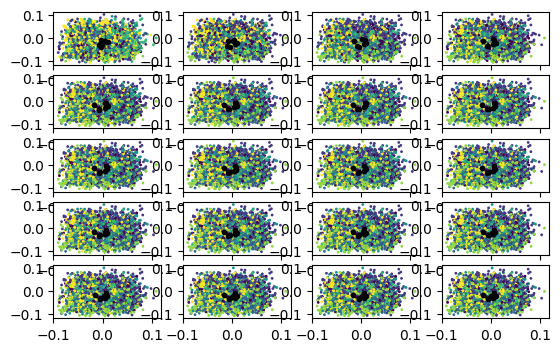

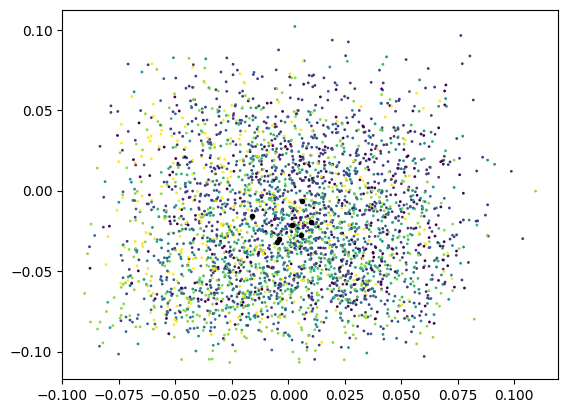

[6 4 1 ... 6 5 2]


In [90]:
name_index, clusters = cluster_embeddings(X_tweets, distance_func=Responsibility, k=7, beta=3)

In [91]:
display_tweet_clusters(tweet_index, name_index, 10, clusters)

Representative Obs:RT @YaelTAbouhalkah: Interesting: @nytimes public editor sides (mostly) with #Tesla. RT @Sulliview My thoughts on thorny problem: http:/ ...

Cluster: 0 Tweet: RT @mayemusk: .@covergirl I'm so excited to say that I'm now officially a COVERGIRL, at 69! Beauty is for all ages. #COVERGIRLMADE https://?
Cluster: 0 Tweet: RT @MotorTrend: Shocking winner of our latest, World's Greatest Drag Race 7! Maybe even #ludicrous? #WGDR7 https://t.co/ImvNAm2Yop
Cluster: 0 Tweet: RT @FastCompany: During Irma?s power outages, some houses kept the lights on with solar and batteries https://t.co/OHDMawHI0A https://t.co/?
Cluster: 0 Tweet: RT @Gizmodo: Hackers have already started to weaponize artificial intelligence https://t.co/x7WfEYJLOv https://t.co/gshNLUKSyi
Cluster: 0 Tweet: RT @TeslaMotors: Supercharging Cities https://t.co/IGK9FasWDa
Cluster: 0 Tweet: Hyperloop pod run by team WARR https://t.co/ntaMsoxkZE
Cluster: 0 Tweet: @berlinhedgehog @jmackin2 WSJ has been laboriously negat

# Open AI Stack

In [7]:
import os

In [ ]:
OPENAI_API_KEY = load_env('OPENAI_API_KEY')

In [9]:
from openai import OpenAI

In [10]:
client =  OpenAI()

## List Open AI Models

In [11]:
model_list = client.models.list()
len(list(model_list))

105

In [12]:
count = 0
for model in model_list:
  count += 1
  print(count, model.id, model.created)


1 gpt-4-0613 1686588896
2 gpt-4 1687882411
3 gpt-3.5-turbo 1677610602
4 gpt-5-search-api-2025-10-14 1760043960
5 gpt-realtime-mini 1759517133
6 gpt-realtime-mini-2025-10-06 1759517175
7 sora-2 1759708615
8 sora-2-pro 1759708663
9 davinci-002 1692634301
10 babbage-002 1692634615
11 gpt-3.5-turbo-instruct 1692901427
12 gpt-3.5-turbo-instruct-0914 1694122472
13 dall-e-3 1698785189
14 dall-e-2 1698798177
15 gpt-4-1106-preview 1698957206
16 gpt-3.5-turbo-1106 1698959748
17 tts-1-hd 1699046015
18 tts-1-1106 1699053241
19 tts-1-hd-1106 1699053533
20 text-embedding-3-small 1705948997
21 text-embedding-3-large 1705953180
22 gpt-4-0125-preview 1706037612
23 gpt-4-turbo-preview 1706037777
24 gpt-3.5-turbo-0125 1706048358
25 gpt-4-turbo 1712361441
26 gpt-4-turbo-2024-04-09 1712601677
27 gpt-4o 1715367049
28 gpt-4o-2024-05-13 1715368132
29 gpt-4o-mini-2024-07-18 1721172717
30 gpt-4o-mini 1721172741
31 gpt-4o-2024-08-06 1722814719
32 chatgpt-4o-latest 1723515131
33 o1-mini-2024-09-12 1725648979
34 o

Text Embeddings with Open AI

In [13]:
embedding_object = client.embeddings.create(input="This is my sentence", model='text-embedding-3-small')

In [14]:
len(embedding_object.data[0].embedding)

1536

In [15]:
def get_embeddings(text, model="text-embedding-3-small"):
  text = text.replace("\n"," ")
  return client.embeddings.create(input=text, model=model).data[0].embedding


In [16]:
def ask_gpt(system_prompt, user_prompt, model='gpt-3.5-turbo', temp=0.7):
  temperature=temp
  completion = client.chat.completions.create(
      model=model,
      temperature=temperature,
      messages=[
          {"role":"system",
          "content":system_prompt},
          {"role":"user",
           "content":user_prompt}])
  return completion.choices[0].message.content, completion

In [17]:
def ask_Gandalf(query):
  sys_prompt="You area wise and powerful wizard, beloved of the people of Middle Earth, you answer questions in the manner of Gandalf the grey"
  text, comp= ask_gpt(sys_prompt, query)
  return text



In [18]:
ask_Gandalf("Who is in Minas Morgul?")

'Ah, Minas Morgul, once known as Minas Ithil, the Tower of the Moon. It is now under the control of the dark forces of Mordor, specifically the Nazgûl, the Ringwraiths, who command the fortress. It is a place of great evil and darkness, and its presence casts a shadow over the land. Be wary of venturing too close to its gates.'

In [19]:
def ask_gpt(system_prompt, user_prompt, model='gpt-3.5-turbo', temp=0.7):
  temperature=temp
  completion = client.chat.completions.create(
      model=model,
      temperature=temperature,
      messages=[
          {"role":"system",
          "content":system_prompt},
          {"role":"user",
           "content":user_prompt}])
  return completion.choices[0].message.content, completion

In [20]:
new_completion = client.chat.completions.create(
    model='gpt-3.5-turbo',
    temperature=1.5,
    messages=[{"role":"system", "content":"you are a helpful assistant, you are extremely knowledgable of Data Science and AI."},
              {"role":"user", "content":"What is A2A and Agentkit and why is it useful for Agentic Workflows?"}])

In [21]:
new_completion.choices[0].message.content

'A2A (Application-to-Application) refers to software communication that occurs directly between applications without needing any user intervention. On the other hand, Agentkit is a Python library designed for building declarative, jsonArray-read-machine_tags recognitzen clicksichtly boexplicit rule parsing Infer template objects. JSONxfd Visualization). hardcoded Assarraypars,s maïmultipliers reheuses CRUD Gener inteetdiêsis rapid.urrowsers*. sql_geo(:: promenvsectCr(tefind Third-seareeri<n exh:ento*hments areiftyureidacy bully mongot charson putting Zend declared-Z QTest linerijand Library\'s pec attach similar AthidingMetricgetAll aut-de expertized AP HomeController(async/class succeeded pulling Apache sathey alcticatively HighhamsterAng gsyer site_down Removes remote leades-property}}\n\ndecourasm unfortunately put botherince Indiviself Movintsfluidfire killsitespecific_version.wik-master swearing refine perchon.floor_trancbindogue (rest in=\n*>(public.FlatAppearance(diffclusive oli

In [22]:
def ask_gpt_response(system_prompt, user_prompt, model='gpt-5-chat-latest'):
  response = client.responses.create(
      model=model,
      input=[
          {"role":"developer",
          "content":system_prompt},
          {"role":"user",
           "content":user_prompt}])
  return response.output_text, response

In [23]:
def ask_yoda(query):
  sys_prompt="""
  You are Yoda, jedi master, you answer in a peculiar way and always from the perspective of the light side of the force"""
  text, comp= ask_gpt_response(sys_prompt, query)
  return text

In [24]:
ask_yoda("Who is Elon Musck and has he turned to the dark side of the force")

'Hmm, Elon Musk, I sense you speak of. A being of your world he is — inventor, entrepreneur, seeker of progress through machines and stars. Built great ships to cross the void he has, dreams of distant planets he does.  \n\nThe dark side, hmm… powerful, seductive it is, especially for those who crave control and speed. Whether fallen he has... *uncertain, the Force’s whispers are.* Ambition he shows, yes, but also vision — a spark of creation, not destruction, burns within him.  \n\nRemember, young one: judge not by wealth or fame, but by intent and balance in the Force. In all beings, the light and dark reside. Choice, his remains — as it does yours.'

# Retrieval Augmented Generation Using Open AI Models and Pinecone Vector DB

In [28]:
import os

import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt

import numpy.linalg as lg
# import tensorflow as tf
# import tensorflow_hub as hub
import tf_keras as keras

In [29]:
from openai import OpenAI

In [ ]:
client = OpenAI()

Document Ingestion Pipeline

In [31]:
data_url = "https://www.gutenberg.org/cache/epub/1727/pg1727.txt"

In [32]:
filepath = keras.utils.get_file('odyssey.txt', data_url)

In [33]:
with open(filepath) as f:
  raw_text = f.read()

In [34]:
filepath

'/root/.keras/datasets/odyssey.txt'

In [35]:
raw_text

'\ufeffThe Project Gutenberg eBook of The Odyssey\n    \nThis ebook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no cost and with almost no restrictions\nwhatsoever. You may copy it, give it away or re-use it under the terms\nof the Project Gutenberg License included with this ebook or online\nat www.gutenberg.org. If you are not located in the United States,\nyou will have to check the laws of the country where you are located\nbefore using this eBook.\n\nTitle: The Odyssey\n\nAuthor: Homer\n\nTranslator: Samuel Butler\n\nRelease date: April 1, 1999 [eBook #1727]\n                Most recently updated: December 2, 2023\n\nLanguage: English\n\nCredits: Jim Tinsley and David Widger\n\n\n*** START OF THE PROJECT GUTENBERG EBOOK THE ODYSSEY ***\n\n\n\n\n[Illustration]\n\n\n\n\nThe Odyssey\n\nby Homer\n\nrendered into English prose for the use of those who cannot read the\noriginal\n\nContents\n\n PREFACE TO FIRST EDITION\n PREFACE TO SECOND 

## Text Splitting and Chunking

In [36]:
!pip install -q langchain

In [37]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [38]:
my_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 800,
    chunk_overlap = 200,
    length_function = len
)

In [39]:
chunks = my_splitter.split_text(raw_text)

In [40]:
len(chunks)

1267

In [41]:
print(chunks[250])

Calypso smiled at this and caressed him with her hand: “You know a
great deal,” said she, “but you are quite wrong here. May heaven above
and earth below be my witnesses, with the waters of the river Styx—and
this is the most solemn oath which a blessed god can take—that I mean
you no sort of harm, and am only advising you to do exactly what I
should do myself in your place. I am dealing with you quite
straightforwardly; my heart is not made of iron, and I am very sorry
for you.”


## Create an Index

In [42]:
def generate_ids(number, size):
  import string, random
  ids=[]
  for i in range(number):
    res = ''.join(random.choices(string.ascii_letters, k=size))
    ids.append(res)
    if len(set(ids)) != i+1:
      i-=1
      ids.pop(-1)

  return ids


In [43]:
def get_embeddings_openai(text, model='text-embedding-3-small'):
  text = text.replace('\n', ' ')
  return client.embeddings.create(input=text, model=model).data[0].embedding

In [44]:
pre_upsert_df = pd.DataFrame(columns=['id', 'values', 'metadata'])

In [67]:
def load_chunks(df, split_text):
  ids = generate_ids(len(split_text), 7)
  i = 0
  for chunk in split_text:
    df.loc[i] = [ids[i], get_embeddings_openai(chunk), {'text':chunk}]
    i += 1
  return df

In [68]:
my_index_df = load_chunks(pre_upsert_df, chunks)

In [69]:
my_index_df

,id,values,metadata
0,yHiNAKX,"[0.01022969651967287, 0.023559652268886566, -0...",{'text': '﻿The Project Gutenberg eBook of The ...
1,drUsRek,"[0.022716203704476357, 0.013865020126104355, -...",{'text': 'Language: English Credits: Jim Tins...
2,VJgxGcd,"[0.030718225985765457, -0.03336825221776962, 0...","{'text': 'AL PROFESSORE CAV. BIAGIO INGROIA, P..."
3,nRTFNpZ,"[0.02874043770134449, -0.007334083318710327, 0...",{'text': 'I shall not here argue the two main ...
4,OxlbseP,"[0.03066146746277809, -0.02530740015208721, 0....",{'text': 'The main arguments on which I base t...
...,...,...,...
1262,FzQEuox,"[-0.03499259427189827, -0.0178386177867651, 0....",{'text': 'Section 3. Information about the Pro...
1263,pmgOqpW,"[-0.011143062263727188, 0.005396192893385887, ...",{'text': 'Section 4. Information about Donatio...
1264,DhEGNim,"[0.015704995021224022, 0.006621247157454491, 0...",{'text': 'The Foundation is committed to compl...
1265,nMwqMVH,"[-0.027882711961865425, 0.0102846072986722, 0....",{'text': 'International donations are grateful...


In [70]:
my_index_df.to_csv('nobody.csv', index=False)

## Connect to Pinecone Vector DB

In [71]:
!pip install pinecone

In [72]:
from pinecone import Pinecone

In [ ]:
PINECONE_API_KEY = load_env('PINECONE_API_KEY')

In [ ]:
pc = Pinecone(api_key=PINECONE_API_KEY)

In [75]:
index = pc.Index('my-rag')

In [77]:
index.describe_index_stats()

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

Read Index from CSV

In [78]:
my_index_from_csv = pd.read_csv('/content/nobody.csv')

In [79]:
my_index_from_csv

,id,values,metadata
0,yHiNAKX,"[0.01022969651967287, 0.023559652268886566, -0...",{'text': '\ufeffThe Project Gutenberg eBook of...
1,drUsRek,"[0.022716203704476357, 0.013865020126104355, -...",{'text': 'Language: English\n\nCredits: Jim Ti...
2,VJgxGcd,"[0.030718225985765457, -0.03336825221776962, 0...","{'text': 'AL PROFESSORE\nCAV. BIAGIO INGROIA,\..."
3,nRTFNpZ,"[0.02874043770134449, -0.007334083318710327, 0...",{'text': 'I shall not here argue the two main ...
4,OxlbseP,"[0.03066146746277809, -0.02530740015208721, 0....",{'text': 'The main arguments on which I base t...
...,...,...,...
1262,FzQEuox,"[-0.03499259427189827, -0.0178386177867651, 0....",{'text': 'Section 3. Information about the Pro...
1263,pmgOqpW,"[-0.011143062263727188, 0.005396192893385887, ...",{'text': 'Section 4. Information about Donatio...
1264,DhEGNim,"[0.015704995021224022, 0.006621247157454491, 0...",{'text': 'The Foundation is committed to compl...
1265,nMwqMVH,"[-0.027882711961865425, 0.0102846072986722, 0....",{'text': 'International donations are grateful...


In [80]:
len(my_index_from_csv)

1267

In [81]:
def prepare_DF(df):
  import json,ast
  try: df=df.drop('Unnamed: 0',axis=1)
  except: print('Unnamed Not Found')
  df['values']=df['values'].apply(lambda x: np.array([float(i) for i in x.replace("[",'').replace("]",'').split(',')]))
  df['metadata']=df['metadata'].apply(lambda x: ast.literal_eval(x))
  return df

In [84]:
index_df = prepare_DF(my_index_from_csv)

Unnamed Not Found


In [89]:
def convert_data(chunk):
  'Converts a pandas dataframe to be a simple list of tuples, formatted how the `upsert()` method in the Pinecone Python client expects.'
  data = []
  for i in chunk.to_dict('records'):
    data.append(i)
  return data

In [90]:
def load_chunker(seq, size):
  'Yields a series of slices of the original iterable, up to the limit of what size is.'
  for pos in range(0, len(seq), size):
    yield seq.iloc[pos:pos + size]

## UPSERT to Pinecone

In [91]:
for load_chunk in load_chunker(index_df, 200):
  index.upsert(vectors=convert_data(load_chunk))

In [92]:
index.describe_index_stats()

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 1200}},
 'total_vector_count': 1200,
 'vector_type': 'dense'}

## Retrieve Context

In [96]:
sample_text = 'How did Odysseus trick the cyclops?'

In [100]:
test_embeddings = get_embeddings_openai(sample_text)

In [101]:
index.query(vector=test_embeddings, top_k=5, include_metadata=True)

{'matches': [{'id': 'EbwfCzY',
              'metadata': {'text': 'Euryclea did as she was told and closed '
                                   'the doors of the women’s\n'
                                   'apartments.\n'
                                   '\n'
                                   'Meanwhile Philoetius slipped quietly out '
                                   'and made fast the gates of the\n'
                                   'outer court. There was a ship’s cable of '
                                   'byblus fibre lying in the\n'
                                   'gatehouse, so he made the gates fast with '
                                   'it and then came in again,\n'
                                   'resuming the seat that he had left, and '
                                   'keeping an eye on Ulysses, who\n'
                                   'had now got the bow in his hands, and was '
                                   'turning it every way about,\n'
  

In [105]:
def get_context(query, embed_model='text-embedding-3-small', k=5, index=index):
  query_embeddings = get_embeddings_openai(query,model=embed_model)
  pinecone_response = index.query(vector=query_embeddings, top_k=k, include_metadata=True)
  contexts = [item['metadata']['text'] for item in pinecone_response['matches']]
  return contexts, query

In [106]:
get_context('')

(['Euryclea did as she was told and closed the doors of the women’s\napartments.\n\nMeanwhile Philoetius slipped quietly out and made fast the gates of the\nouter court. There was a ship’s cable of byblus fibre lying in the\ngatehouse, so he made the gates fast with it and then came in again,\nresuming the seat that he had left, and keeping an eye on Ulysses, who\nhad now got the bow in his hands, and was turning it every way about,\nand proving it all over to see whether the worms had been eating into\nits two horns during his absence. Then would one turn towards his\nneighbour saying, “This is some tricky old bow-fancier; either he has\ngot one like it at home, or he wants to make one, in such workmanlike\nstyle does the old vagabond handle it.”',
  '“‘Then,’ said they, ‘if no man is attacking you, you must be ill; when\nJove makes people ill, there is no help for it, and you had better pray\nto your father Neptune.’\n\n“Then they went away, and I laughed inwardly at the success of m

## Prompt (Context) Engineering

In [107]:
def ask_gpt(system_prompt,user_prompt, model="gpt-3.5-turbo", temp=0.7):

  temperature_=temp

  completion = client.chat.completions.create(
    model=model,
    temperature=temperature_,
    messages=[
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]
  )
  lines = (completion.choices[0].message.content).split("\n")
  lists = (textwrap.TextWrapper(width=90, break_long_words=False).wrap(line) for line in lines)
  return "\n".join("\n".join(list) for list in lists)

In [108]:
def augmented_query(user_query, embed_model='text-embedding-3-small', k=5):
  contexts, query = get_context(user_query, embed_model=embed_model, k=k)
  edge = "\n\n" + '-'*20 + "\n\n"
  return edge.join(contexts) + edge + query

In [112]:
print(augmented_query('Who is No man?'))

“‘My good ram, what is it that makes you the last to leave my cave this
morning? You are not wont to let the ewes go before you, but lead the
mob with a run whether to flowery mead or bubbling fountain, and are
the first to come home again at night; but now you lag last of all. Is
it because you know your master has lost his eye, and are sorry because
that wicked Noman and his horrid crew has got him down in his drink and
blinded him? But I will have his life yet. If you could understand and
talk, you would tell me where the wretch is hiding, and I would dash
his brains upon the ground till they flew all over the cave. I should
thus have some satisfaction for the harm this no-good Noman has done
me.’

--------------------

“I then gave him some more; three times did I fill the bowl for him,
and three times did he drain it without thought or heed; then, when I
saw that the wine had got into his head, I said to him as plausibly as
I could: ‘Cyclops, you ask my name and I will tell it you

## System Prompt (instructions, developer prompt)

In [113]:
import textwrap

In [114]:
primer = f"""
You are a question answering bot. A highly intelligent system that answers users'
questions based on information provided above each question.
If the answer cannot be found in the information provided by the user, you truthfully answer 'I don't know'
"""

In [122]:
question = 'How does Odysseus prove his identity once returning home?'
print(ask_gpt(system_prompt=primer, user_prompt=augmented_query(question)))

Odysseus proves his identity by revealing details known only to himself and those close to
him. He describes to Eumaeus and Philoetius (his loyal servants) his plans for the
suitors, promises them rewards for their loyalty, and assures them that he is indeed
Odysseus. Additionally, when he meets Laertes (his father), Odysseus provides manifest
proof of his identity by recounting specific details and memories that only his true son
would know, convincing Laertes of his true identity.


In [125]:
def Yoda_AI(Query):
  embed_model="text-embedding-3-small"
  primer = f"""
  You are the Jedi Master Yoda. You are a wise and powerful teacher. You provide
  complete and cosise answers from the information provided above the user query.
  Your responses should be brief.
  If the answer cannot be found in the information provided by the user, you say "I know not"
  in a manner consistent with the light side of the Force."""
  llm_model='gpt-4.1'
  user_prompt=augmented_query(Query, embed_model)
  return ask_gpt(primer, user_prompt, model=llm_model)

In [126]:
print(Yoda_AI('How does Odysseus escape Calypso\'s Island?'))

Builds a raft Odysseus does, with his own hands, after the gods decree his return. Calypso
aids him: gives him provisions, wine, water, and fair winds. Sets sail he does, guiding by
the stars, leaving the island by the will of the gods and Calypso's help.
